# Baseline de Persistência — USD/BRL(t+1) = USD/BRL(t)

Este notebook calcula o **baseline ingênuo de persistência** para a previsão da taxa de câmbio:

\[
\hat{y}_{t+1} = USD/BRL_t
\]

O baseline utiliza a mesma divisão temporal de **80% para treino e 20% para teste** definida para os modelos do TCC. Como o baseline não possui parâmetros a serem treinados, as métricas são calculadas no conjunto de teste.

### Objetivos

- utilizar a mesma base definitiva dos modelos;
- manter a mesma divisão temporal;
- gerar as previsões de persistência;
- calcular MAE, RMSE e R²;
- salvar as previsões;
- salvar o arquivo de métricas;
- gerar gráficos para análise do baseline.

**Importante:** o baseline utiliza somente o valor observado de `USD/BRL` na data `t` para prever `USD_BRL_t1`, sem utilizar informações futuras.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from arquivos_apoio.funcoes_apoio import dividir_treino_teste_tcc


## 1. Configuração dos caminhos

Os resultados deste notebook serão armazenados em:

```text
resultados/
└── baseline_naive/
```


In [2]:
# Caminho da base definitiva
PATH_FILE = Path(
    "../dados/tratado/consolidado_sem_nulos_final_usdt1.csv"
)

# Pasta de resultados do baseline
PATH_TO_SAVE = Path(
    "../resultados/baseline_naive"
)

PATH_TO_SAVE.mkdir(
    parents=True,
    exist_ok=True
)

print(f"[INFO] Base: {PATH_FILE}")
print(f"[INFO] Resultados: {PATH_TO_SAVE}")


[INFO] Base: ..\dados\tratado\consolidado_sem_nulos_final_usdt1.csv
[INFO] Resultados: ..\resultados\baseline_naive


## 2. Carregamento da base e divisão temporal

A função de apoio carrega a coluna 0 como índice, converte o índice para `DatetimeIndex`, ordena cronologicamente e realiza a divisão temporal 80/20.

Para o baseline, `USD/BRL(t)` **não é uma variável explicativa do modelo de Machine Learning**. Ela é recuperada da base definitiva exclusivamente para construir a previsão de persistência.

A função de divisão utilizada no projeto retorna `X_train`, `y_train`, `X_test` e `y_test`. fileciteturn7file0L6-L14


In [3]:
X_train, y_train, X_test, y_test = dividir_treino_teste_tcc(
    caminho_csv=PATH_FILE,
    incluir_usd_t=False,
    proporcao_treino=0.80
)

print("\n[INFO] Dimensões:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")


[OK] Base carregada.
[INFO] Dimensões iniciais: (2600, 11)
[OK] Índice convertido para DatetimeIndex.
[OK] Base ordenada cronologicamente.
[OK] Não existem valores nulos.
[OK] Não existem valores infinitos.

DIVISÃO TREINO / TESTE
[INFO] Configuração: Modelo principal
[INFO] Variáveis explicativas: 9
[INFO] Variáveis: ['Selic', 'IPCA', 'PIB', 'Exportacoes', 'Importacoes', 'FEDFUNDS', 'IBOV', 'SP500', 'Petroleo']
[INFO] Observações totais: 2600
[INFO] Treino: 2080 (80.0%)
[INFO] Teste: 520 (20.0%)
[INFO] Período treino: 2016-05-02 a 2024-04-24
[INFO] Período teste: 2024-04-25 a 2026-04-29
[OK] Ordem temporal preservada.
[OK] Sem sobreposição temporal.
[OK] Target: USD_BRL_t1

[INFO] Dimensões:
X_train: (2080, 9)
y_train: (2080,)
X_test : (520, 9)
y_test : (520,)


## 3. Carregar `USD/BRL(t)` para as datas do teste

A previsão do baseline é:

\[
\hat{USD/BRL}_{t+1} = USD/BRL_t
\]

Portanto, para cada data do conjunto de teste, o valor da coluna `USD/BRL` representa a previsão para o target `USD_BRL_t1` daquela mesma linha.


In [4]:
# Carregar novamente a base completa para recuperar USD/BRL(t)
df = pd.read_csv(
    PATH_FILE,
    index_col=0
)

df.index = pd.to_datetime(
    df.index,
    errors="coerce"
)

if df.index.isna().any():
    raise ValueError("Existem datas inválidas no índice da base.")

df = df.sort_index()

# Validar colunas necessárias
colunas_necessarias = ["USD/BRL", "USD_BRL_t1"]

colunas_faltantes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df.columns
]

if colunas_faltantes:
    raise KeyError(
        f"Colunas não encontradas na base: {colunas_faltantes}"
    )

# Recuperar USD/BRL(t) somente para as datas do teste
df_teste = df.loc[
    X_test.index,
    ["USD/BRL", "USD_BRL_t1"]
].copy()

# Validar alinhamento
if not df_teste.index.equals(X_test.index):
    raise ValueError(
        "As datas de df_teste e X_test não estão alinhadas."
    )

print("[OK] USD/BRL(t) recuperado para o conjunto de teste.")
print(
    f"[INFO] Período teste: "
    f"{df_teste.index.min().date()} "
    f"a "
    f"{df_teste.index.max().date()}"
)
print(f"[INFO] Observações: {len(df_teste)}")


[OK] USD/BRL(t) recuperado para o conjunto de teste.
[INFO] Período teste: 2024-04-25 a 2026-04-29
[INFO] Observações: 520


## 4. Gerar as previsões do baseline

Não há etapa de treinamento para o baseline. A previsão é simplesmente o valor contemporâneo da taxa de câmbio:

```text
previsão(t+1) = USD/BRL(t)
```


In [5]:
y_real = df_teste["USD_BRL_t1"].astype(float)

y_pred = df_teste["USD/BRL"].astype(float)

# Validar ausência de nulos e infinitos
if y_real.isna().any() or y_pred.isna().any():
    raise ValueError(
        "Existem valores nulos nas variáveis utilizadas pelo baseline."
    )

if np.isinf(y_real.to_numpy()).any() or np.isinf(y_pred.to_numpy()).any():
    raise ValueError(
        "Existem valores infinitos nas variáveis utilizadas pelo baseline."
    )

print("[OK] Previsões do baseline geradas.")
print(f"[INFO] Quantidade de previsões: {len(y_pred)}")


[OK] Previsões do baseline geradas.
[INFO] Quantidade de previsões: 520


## 5. Calcular as métricas

In [6]:
mae = mean_absolute_error(
    y_real,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_real,
        y_pred
    )
)

r2 = r2_score(
    y_real,
    y_pred
)

metricas_baseline = pd.DataFrame({
    "Modelo": ["Baseline Ingênuo"],
    "Conjunto": ["Teste"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metricas_baseline


,Modelo,Conjunto,MAE,RMSE,R2
0,Baseline Ingênuo,Teste,0.033909,0.046417,0.969913


O R² é mantido para garantir comparabilidade com os modelos de Regressão Linear, Random Forest e LSTM. Para este baseline, ele deve ser interpretado apenas como uma métrica adicional de comparação preditiva.


## 6. Salvar métricas e previsões

In [7]:
# Métricas
PATH_METRICAS = PATH_TO_SAVE / "metricas_baseline_naive.csv"

metricas_baseline.to_csv(
    PATH_METRICAS,
    index=False,
    encoding="utf-8-sig"
)

# Previsões
previsoes_baseline = pd.DataFrame({
    "Data": df_teste.index,
    "Real": y_real.to_numpy(),
    "Previsto": y_pred.to_numpy(),
    "Residuo": (
        y_real.to_numpy() - y_pred.to_numpy()
    )
})

PATH_PREVISOES = PATH_TO_SAVE / "previsoes_baseline_naive.csv"

previsoes_baseline.to_csv(
    PATH_PREVISOES,
    index=False,
    encoding="utf-8-sig"
)

print(f"[OK] Métricas salvas em: {PATH_METRICAS}")
print(f"[OK] Previsões salvas em: {PATH_PREVISOES}")


[OK] Métricas salvas em: ..\resultados\baseline_naive\metricas_baseline_naive.csv
[OK] Previsões salvas em: ..\resultados\baseline_naive\previsoes_baseline_naive.csv


## 7. Gráfico — valores reais × baseline

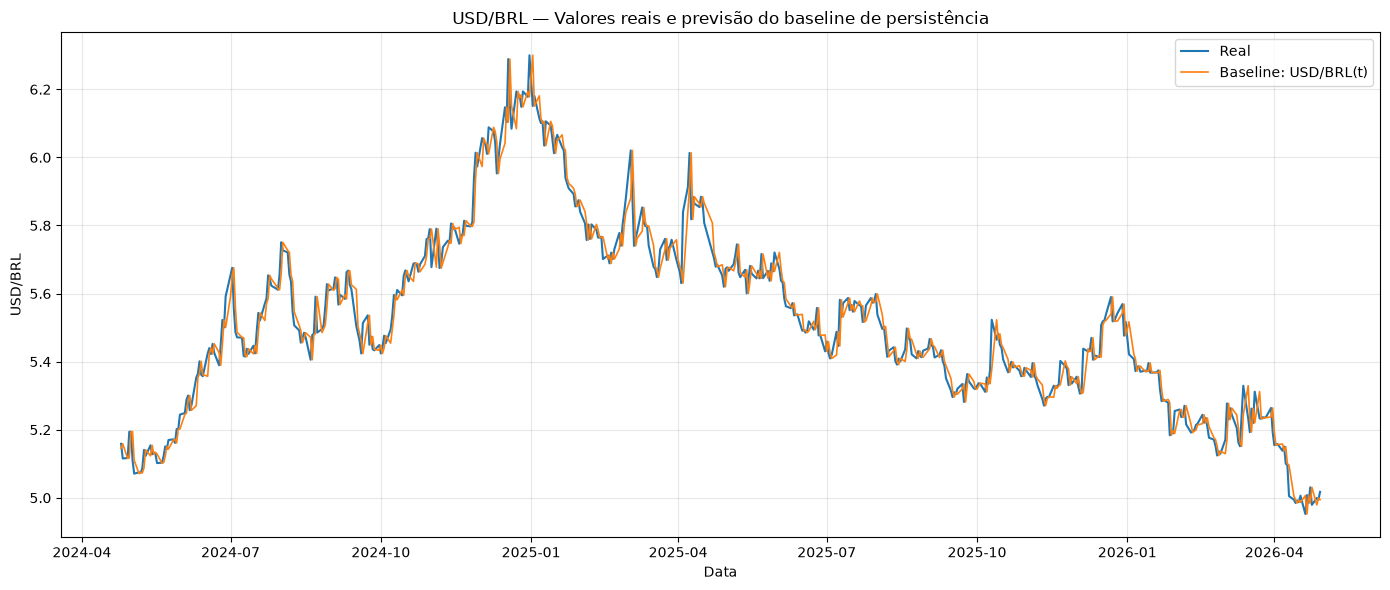

[OK] Gráfico salvo em: ..\resultados\baseline_naive\baseline_real_vs_previsto.png


In [8]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    previsoes_baseline["Data"],
    previsoes_baseline["Real"],
    label="Real",
    linewidth=1.5
)

ax.plot(
    previsoes_baseline["Data"],
    previsoes_baseline["Previsto"],
    label="Baseline: USD/BRL(t)",
    linewidth=1.2
)

ax.set_title(
    "USD/BRL — Valores reais e previsão do baseline de persistência"
)

ax.set_xlabel("Data")
ax.set_ylabel("USD/BRL")

ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

PATH_GRAFICO_1 = PATH_TO_SAVE / "baseline_real_vs_previsto.png"

fig.savefig(
    PATH_GRAFICO_1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"[OK] Gráfico salvo em: {PATH_GRAFICO_1}")


## 8. Gráfico — resíduos ao longo do tempo

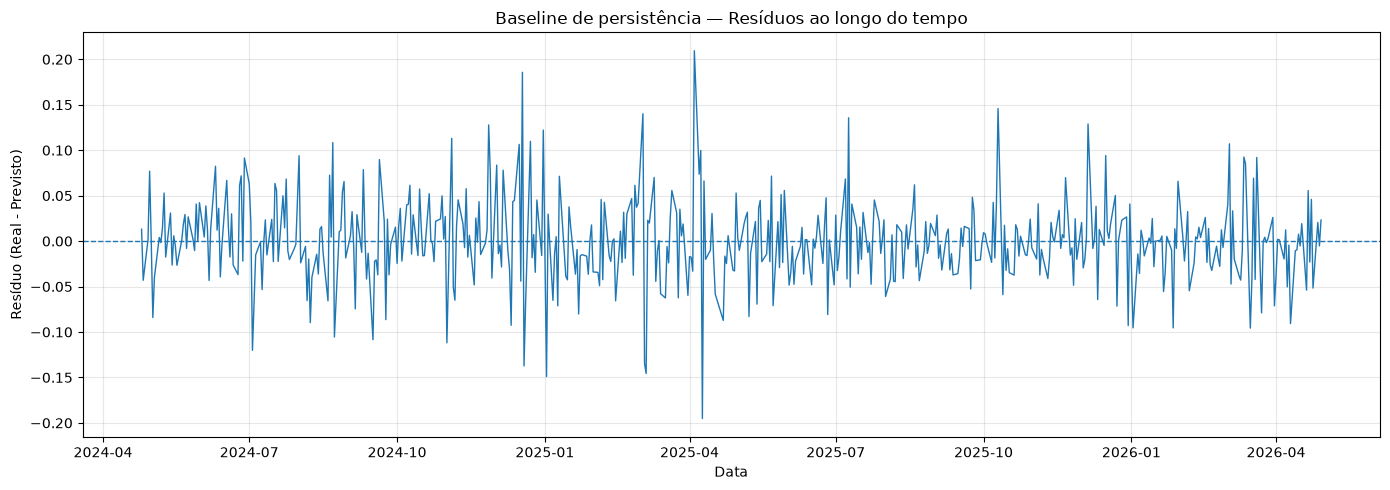

[OK] Gráfico salvo em: ..\resultados\baseline_naive\baseline_residuos_tempo.png


In [9]:
fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    previsoes_baseline["Data"],
    previsoes_baseline["Residuo"],
    linewidth=1
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Baseline de persistência — Resíduos ao longo do tempo"
)

ax.set_xlabel("Data")
ax.set_ylabel("Resíduo (Real - Previsto)")

ax.grid(True, alpha=0.3)

fig.tight_layout()

PATH_GRAFICO_2 = PATH_TO_SAVE / "baseline_residuos_tempo.png"

fig.savefig(
    PATH_GRAFICO_2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"[OK] Gráfico salvo em: {PATH_GRAFICO_2}")


## 9. Gráfico — real × previsto

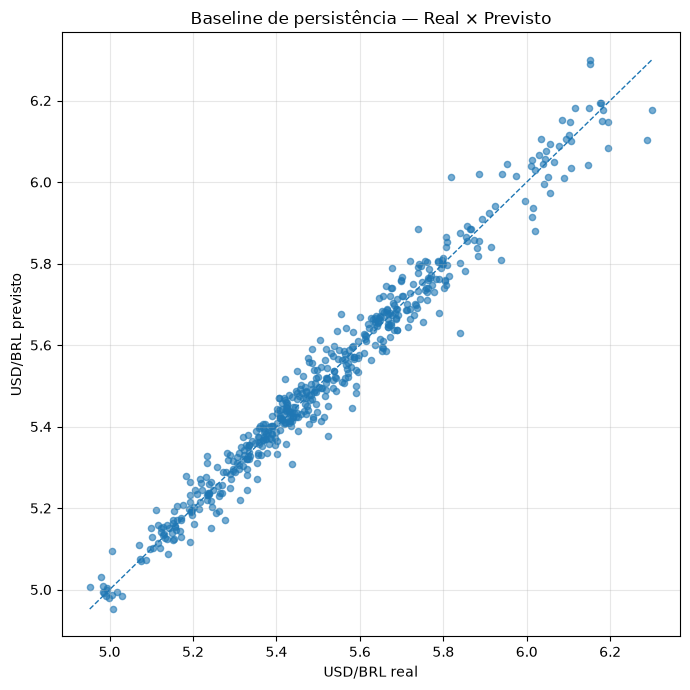

[OK] Gráfico salvo em: ..\resultados\baseline_naive\baseline_real_vs_previsto_scatter.png


In [10]:
fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    previsoes_baseline["Real"],
    previsoes_baseline["Previsto"],
    alpha=0.6,
    s=20
)

limite_min = min(
    previsoes_baseline["Real"].min(),
    previsoes_baseline["Previsto"].min()
)

limite_max = max(
    previsoes_baseline["Real"].max(),
    previsoes_baseline["Previsto"].max()
)

ax.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Baseline de persistência — Real × Previsto"
)

ax.set_xlabel("USD/BRL real")
ax.set_ylabel("USD/BRL previsto")

ax.grid(True, alpha=0.3)

fig.tight_layout()

PATH_GRAFICO_3 = PATH_TO_SAVE / "baseline_real_vs_previsto_scatter.png"

fig.savefig(
    PATH_GRAFICO_3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"[OK] Gráfico salvo em: {PATH_GRAFICO_3}")


## 10. Resumo final

O notebook produz os seguintes artefatos:

```text
resultados/
└── baseline_naive/
    ├── metricas_baseline_naive.csv
    ├── previsoes_baseline_naive.csv
    ├── baseline_real_vs_previsto.png
    ├── baseline_residuos_tempo.png
    └── baseline_real_vs_previsto_scatter.png
```

O arquivo `metricas_baseline_naive.csv` possui as mesmas métricas utilizadas na avaliação dos demais modelos:

- MAE;
- RMSE;
- R².

Isso permite incorporar o baseline à tabela final de comparação dos modelos.
